In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
import os

# Create charts folder for saving PNGs
os.makedirs('../reports/charts', exist_ok=True)

print("✅ Libraries loaded successfully!")

✅ Libraries loaded successfully!


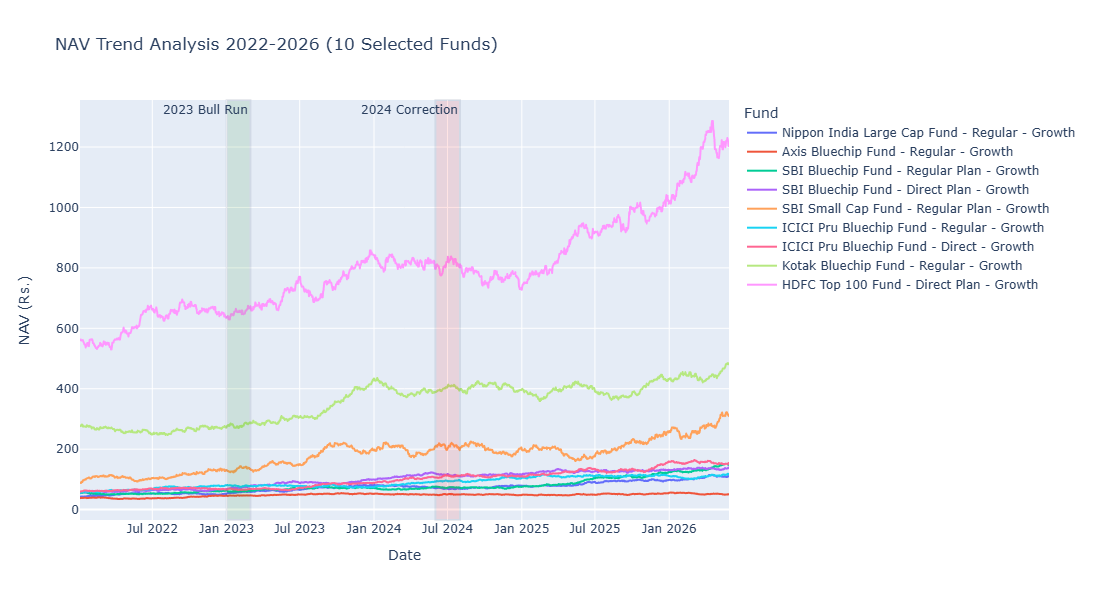

✅ Chart 1 complete!


In [2]:
# Load NAV data
df_nav = pd.read_csv("../data/processed/clean_nav.csv")
df_nav['date'] = pd.to_datetime(df_nav['date'])

# Load fund master for names
df_fund = pd.read_csv("../data/raw/01_fund_master.csv")

# Select 10 funds for clarity
selected_codes = [119551, 119552, 120503, 120504, 125497, 
                  118632, 119092, 120841, 119597, 119598]

df_selected = df_nav[df_nav['amfi_code'].isin(selected_codes)]

# Merge with fund names
df_selected = df_selected.merge(
    df_fund[['amfi_code', 'scheme_name']], 
    on='amfi_code', 
    how='left'
)

# Plot
fig = px.line(
    df_selected, 
    x='date', 
    y='nav', 
    color='scheme_name',
    title='NAV Trend Analysis 2022-2026 (10 Selected Funds)',
    labels={'nav': 'NAV (Rs.)', 'date': 'Date', 'scheme_name': 'Fund'}
)

# Highlight key market events using shapes instead
fig.add_vrect(
    x0="2023-01-01", x1="2023-03-01",
    fillcolor="green", opacity=0.1,
    annotation_text="2023 Bull Run"
)
fig.add_vrect(
    x0="2024-06-01", x1="2024-08-01",
    fillcolor="red", opacity=0.1,
    annotation_text="2024 Correction"
)

fig.update_layout(height=600)
fig.show()

print("✅ Chart 1 complete!")

In [3]:
# Chart 2: AUM Growth by Fund House
df_aum = pd.read_csv("../data/raw/03_aum_by_fund_house.csv")
print(df_aum.head())
print(df_aum.columns.tolist())

         date           fund_house  aum_lakh_crore  aum_crore  num_schemes
0  2022-03-31      SBI Mutual Fund            6.05     605000          186
1  2022-03-31  ICICI Prudential MF            4.65     465000          216
2  2022-03-31     HDFC Mutual Fund            4.35     435000          195
3  2022-03-31      Nippon India MF            2.70     270000          177
4  2022-03-31    Kotak Mahindra MF            2.70     270000          168
['date', 'fund_house', 'aum_lakh_crore', 'aum_crore', 'num_schemes']


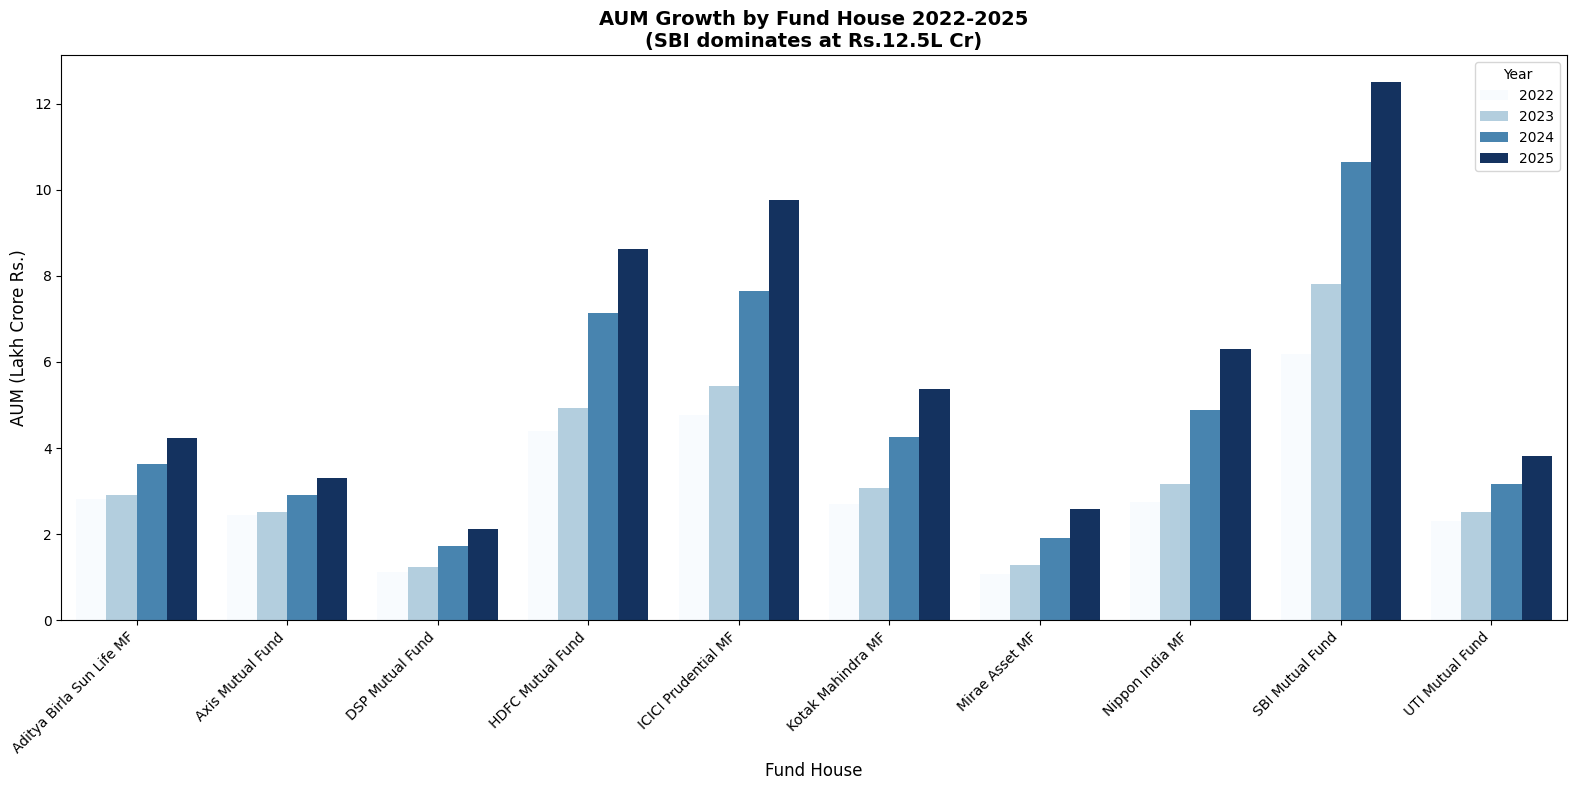

✅ Chart 2 saved → reports/charts/02_aum_growth.png


In [4]:
# Chart 2: AUM Growth by Fund House (Grouped Bar Chart)
df_aum['date'] = pd.to_datetime(df_aum['date'])
df_aum['year'] = df_aum['date'].dt.year

# Filter yearly data
df_yearly = df_aum.groupby(['year', 'fund_house'])['aum_lakh_crore'].mean().reset_index()

# Plot
plt.figure(figsize=(16, 8))
sns.barplot(
    data=df_yearly, 
    x='fund_house', 
    y='aum_lakh_crore', 
    hue='year',
    palette='Blues'
)

plt.title('AUM Growth by Fund House 2022-2025\n(SBI dominates at Rs.12.5L Cr)', 
          fontsize=14, fontweight='bold')
plt.xlabel('Fund House', fontsize=12)
plt.ylabel('AUM (Lakh Crore Rs.)', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.legend(title='Year')
plt.tight_layout()

# Save
plt.savefig('../reports/charts/02_aum_growth.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart 2 saved → reports/charts/02_aum_growth.png")

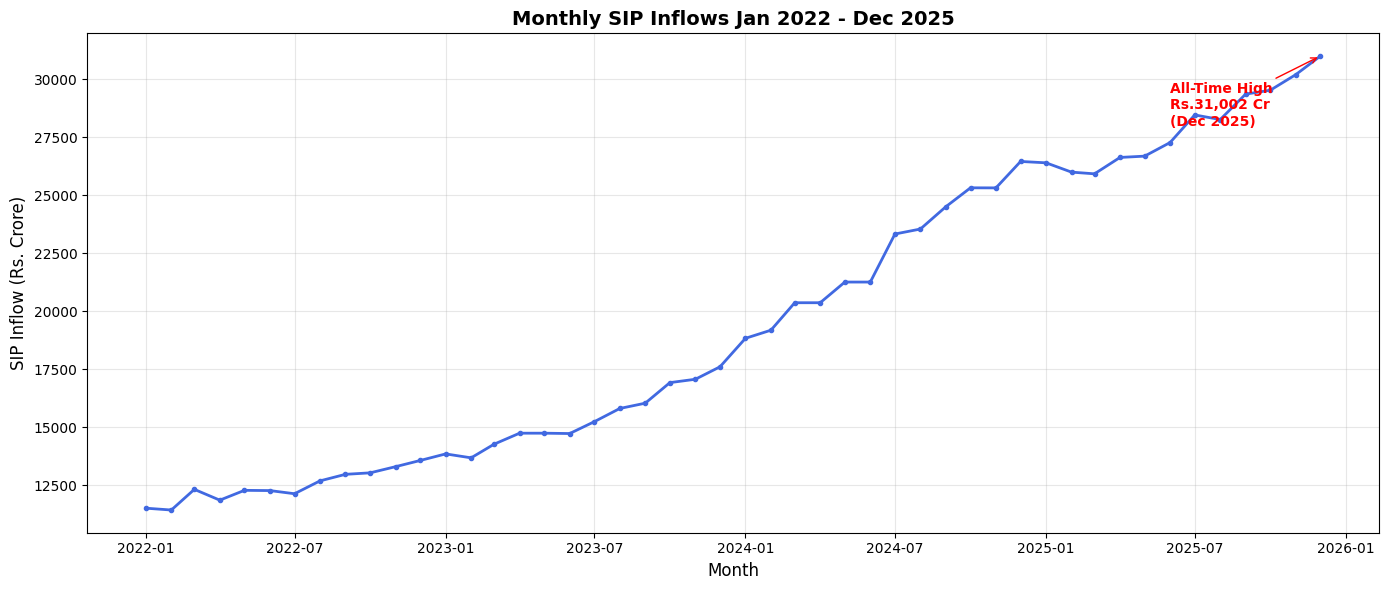

✅ Chart 3 saved → reports/charts/03_sip_inflow.png


In [5]:
# Chart 3: SIP Inflow Time Series
df_sip = pd.read_csv("../data/raw/04_monthly_sip_inflows.csv")
df_sip['month'] = pd.to_datetime(df_sip['month'])

plt.figure(figsize=(14, 6))
plt.plot(df_sip['month'], df_sip['sip_inflow_crore'], 
         color='royalblue', linewidth=2, marker='o', markersize=3)

# Mark all time high
max_idx = df_sip['sip_inflow_crore'].idxmax()
plt.annotate(
    f"All-Time High\nRs.31,002 Cr\n(Dec 2025)",
    xy=(df_sip['month'][max_idx], df_sip['sip_inflow_crore'][max_idx]),
    xytext=(df_sip['month'][max_idx-6], df_sip['sip_inflow_crore'][max_idx]-3000),
    arrowprops=dict(arrowstyle='->', color='red'),
    fontsize=10, color='red', fontweight='bold'
)

plt.title('Monthly SIP Inflows Jan 2022 - Dec 2025', fontsize=14, fontweight='bold')
plt.xlabel('Month', fontsize=12)
plt.ylabel('SIP Inflow (Rs. Crore)', fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.savefig('../reports/charts/03_sip_inflow.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart 3 saved → reports/charts/03_sip_inflow.png")

In [6]:
# Chart 4: Category Inflow Heatmap
df_cat = pd.read_csv("../data/raw/05_category_inflows.csv")
print(df_cat.head())
print(df_cat.columns.tolist())

     month         category  net_inflow_crore
0  2024-04        Large Cap            2413.0
1  2024-04          Mid Cap            3897.0
2  2024-04        Small Cap            3533.0
3  2024-04        Flexi Cap            4947.0
4  2024-04  Large & Mid Cap            4214.0
['month', 'category', 'net_inflow_crore']


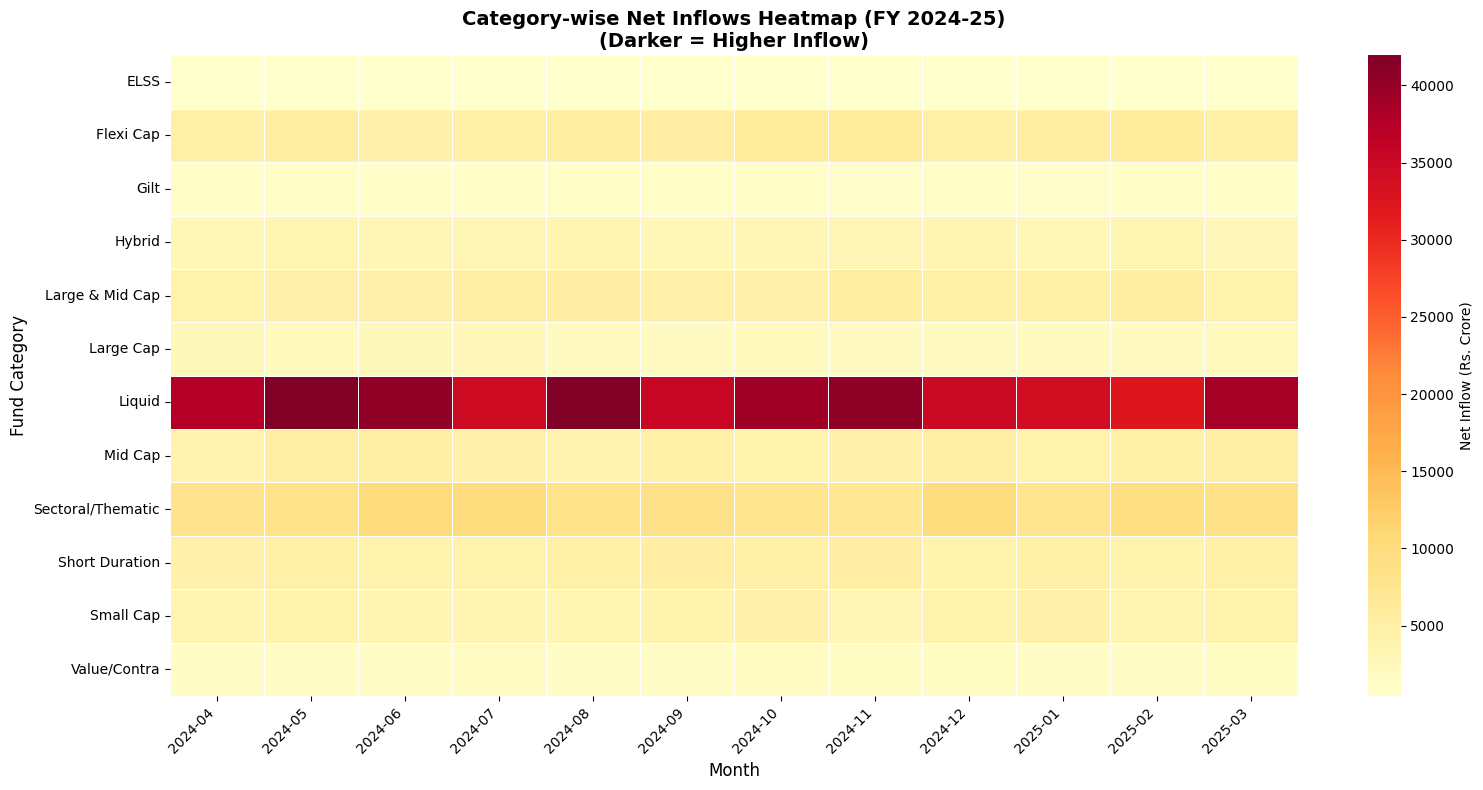

✅ Chart 4 saved → reports/charts/04_category_heatmap.png


In [7]:
# Chart 4: Category Inflow Heatmap
df_cat['month'] = pd.to_datetime(df_cat['month'])
df_cat['month_str'] = df_cat['month'].dt.strftime('%Y-%m')

# Pivot for heatmap
pivot = df_cat.pivot_table(
    index='category', 
    columns='month_str', 
    values='net_inflow_crore'
)

# Plot
plt.figure(figsize=(16, 8))
sns.heatmap(
    pivot,
    cmap='YlOrRd',
    annot=False,
    linewidths=0.5,
    cbar_kws={'label': 'Net Inflow (Rs. Crore)'}
)

plt.title('Category-wise Net Inflows Heatmap (FY 2024-25)\n(Darker = Higher Inflow)', 
          fontsize=14, fontweight='bold')
plt.xlabel('Month', fontsize=12)
plt.ylabel('Fund Category', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()

plt.savefig('../reports/charts/04_category_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart 4 saved → reports/charts/04_category_heatmap.png")

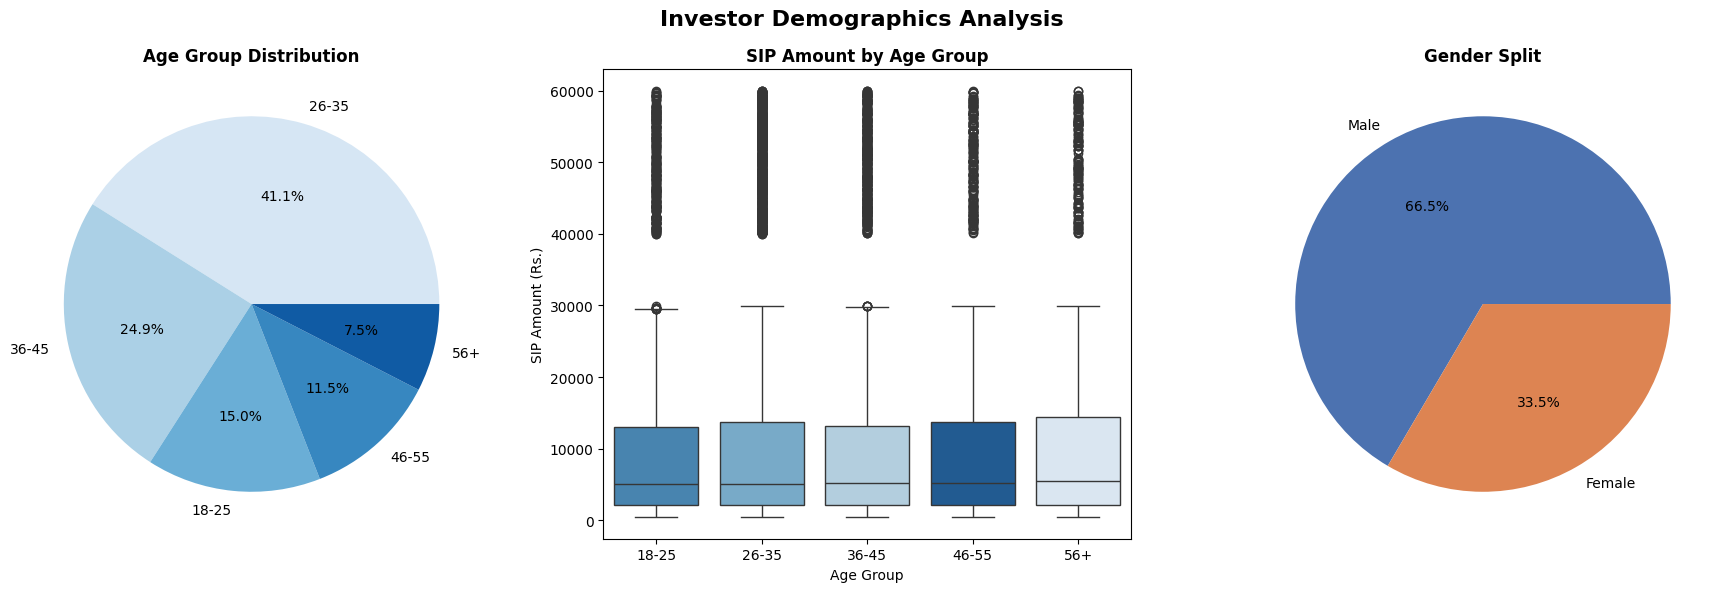

✅ Chart 5 saved → reports/charts/05_investor_demographics.png


In [9]:
# Chart 5: Investor Demographics
df_tx = pd.read_csv("../data/processed/clean_transactions.csv")

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Plot 1: Age group distribution pie chart
age_counts = df_tx['age_group'].value_counts()
axes[0].pie(age_counts, labels=age_counts.index, autopct='%1.1f%%',
            colors=sns.color_palette('Blues', len(age_counts)))
axes[0].set_title('Age Group Distribution', fontweight='bold')

# Plot 2: SIP amount box plot by age group
sip_data = df_tx[df_tx['transaction_type'] == 'SIP']
age_order = ['18-25', '26-35', '36-45', '46-55', '56+']
sns.boxplot(data=sip_data, x='age_group', y='amount_inr',
            order=age_order, hue='age_group', palette='Blues', 
            legend=False, ax=axes[1])
axes[1].set_title('SIP Amount by Age Group', fontweight='bold')
axes[1].set_xlabel('Age Group')
axes[1].set_ylabel('SIP Amount (Rs.)')

# Plot 3: Gender split
gender_counts = df_tx['gender'].value_counts()
axes[2].pie(gender_counts, labels=gender_counts.index, autopct='%1.1f%%',
            colors=['#4C72B0', '#DD8452'])
axes[2].set_title('Gender Split', fontweight='bold')

plt.suptitle('Investor Demographics Analysis', fontsize=16, fontweight='bold')
plt.tight_layout()

plt.savefig('../reports/charts/05_investor_demographics.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart 5 saved → reports/charts/05_investor_demographics.png")

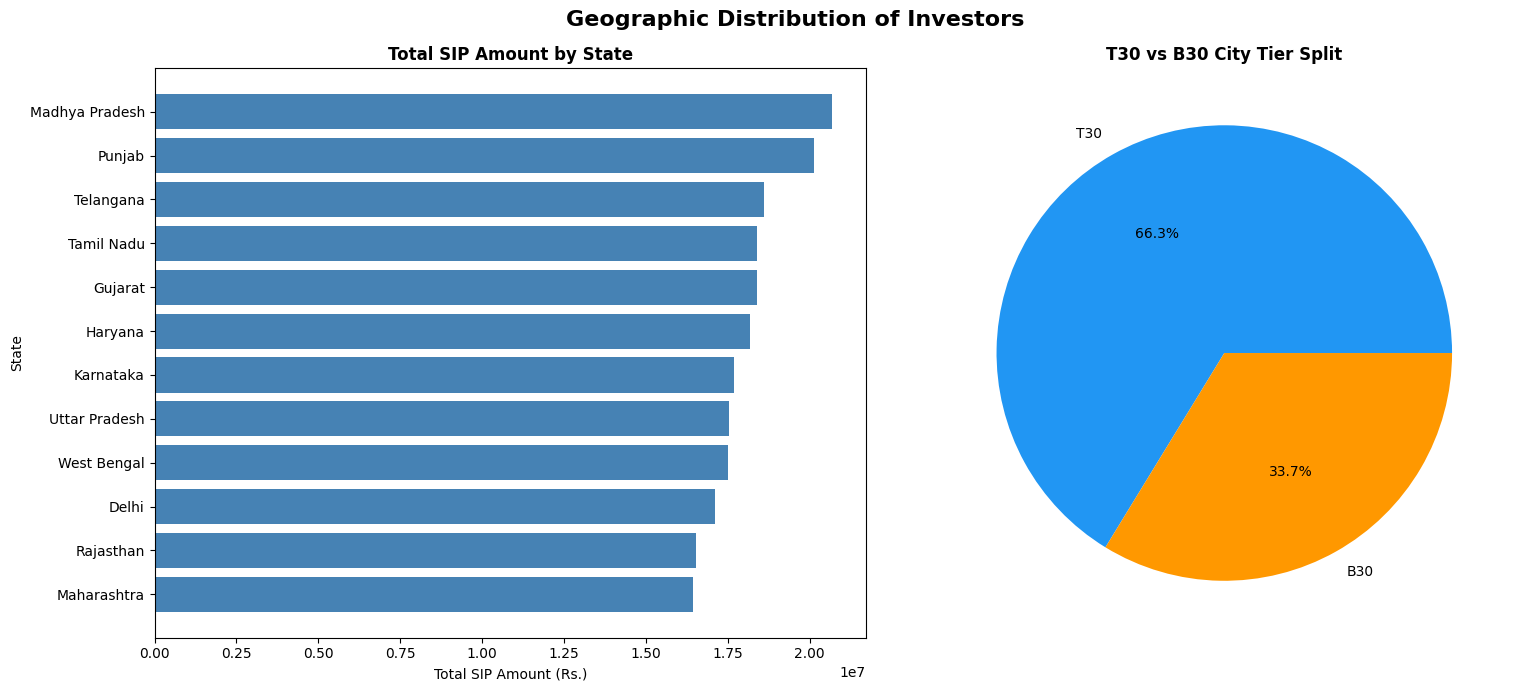

✅ Chart 6 saved → reports/charts/06_geographic_distribution.png


In [10]:
# Chart 6: Geographic Distribution
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Plot 1: SIP amount by state
state_sip = df_tx[df_tx['transaction_type'] == 'SIP'].groupby('state')['amount_inr'].sum().sort_values()

axes[0].barh(state_sip.index, state_sip.values, color='steelblue')
axes[0].set_title('Total SIP Amount by State', fontweight='bold')
axes[0].set_xlabel('Total SIP Amount (Rs.)')
axes[0].set_ylabel('State')

# Plot 2: T30 vs B30 pie chart
tier_counts = df_tx['city_tier'].value_counts()
axes[1].pie(tier_counts, labels=tier_counts.index, autopct='%1.1f%%',
            colors=['#2196F3', '#FF9800'])
axes[1].set_title('T30 vs B30 City Tier Split', fontweight='bold')

plt.suptitle('Geographic Distribution of Investors', fontsize=16, fontweight='bold')
plt.tight_layout()

plt.savefig('../reports/charts/06_geographic_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart 6 saved → reports/charts/06_geographic_distribution.png")

In [11]:
# Chart 7: Folio Count Growth
df_folio = pd.read_csv("../data/raw/06_industry_folio_count.csv")
print(df_folio.head())
print(df_folio.columns.tolist())

     month  total_folios_crore  equity_folios_crore  debt_folios_crore  \
0  2022-01               13.26                 9.28               1.86   
1  2022-04               13.91                 9.74               1.95   
2  2022-07               13.85                 9.69               1.94   
3  2022-10               14.12                 9.88               1.98   
4  2023-01               14.81                10.37               2.07   

   hybrid_folios_crore  others_folios_crore  
0                 0.80                 1.33  
1                 0.83                 1.39  
2                 0.83                 1.38  
3                 0.85                 1.41  
4                 0.89                 1.48  
['month', 'total_folios_crore', 'equity_folios_crore', 'debt_folios_crore', 'hybrid_folios_crore', 'others_folios_crore']


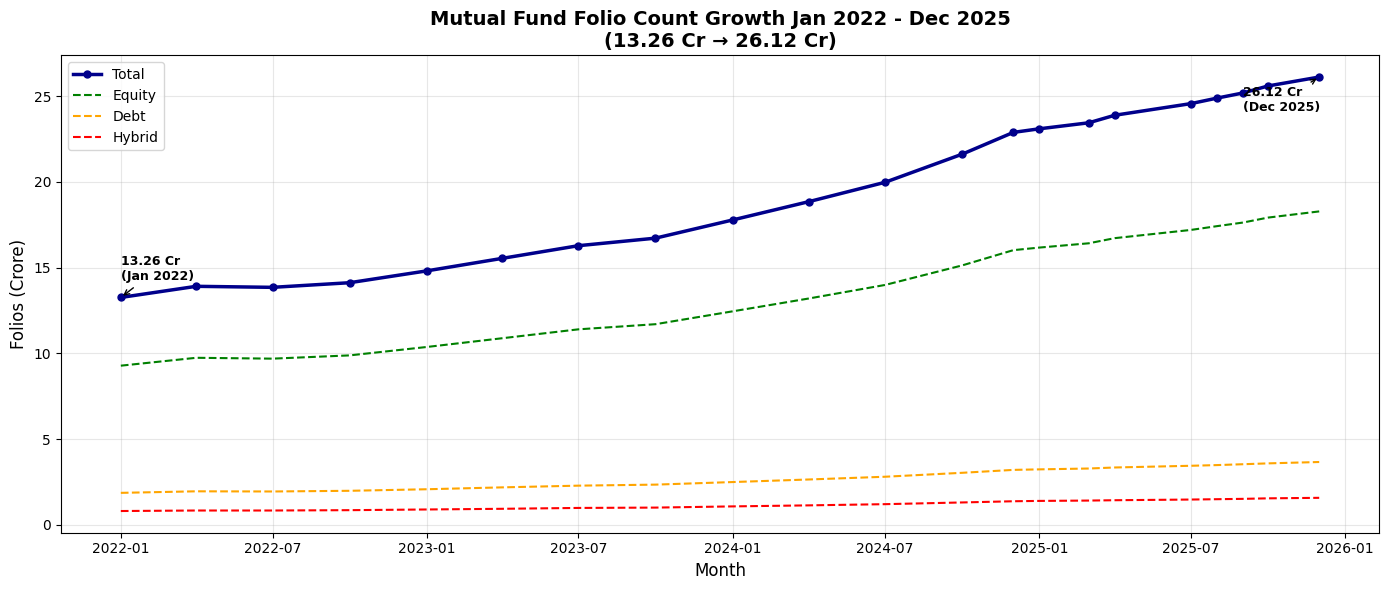

✅ Chart 7 saved → reports/charts/07_folio_growth.png


In [12]:
# Chart 7: Folio Count Growth
df_folio['month'] = pd.to_datetime(df_folio['month'])

plt.figure(figsize=(14, 6))

# Plot total folios
plt.plot(df_folio['month'], df_folio['total_folios_crore'], 
         color='darkblue', linewidth=2.5, marker='o', markersize=5, label='Total')
plt.plot(df_folio['month'], df_folio['equity_folios_crore'], 
         color='green', linewidth=1.5, linestyle='--', label='Equity')
plt.plot(df_folio['month'], df_folio['debt_folios_crore'], 
         color='orange', linewidth=1.5, linestyle='--', label='Debt')
plt.plot(df_folio['month'], df_folio['hybrid_folios_crore'], 
         color='red', linewidth=1.5, linestyle='--', label='Hybrid')

# Mark key milestones
plt.annotate('13.26 Cr\n(Jan 2022)',
    xy=(df_folio['month'].iloc[0], df_folio['total_folios_crore'].iloc[0]),
    xytext=(df_folio['month'].iloc[0], df_folio['total_folios_crore'].iloc[0]+1),
    arrowprops=dict(arrowstyle='->', color='black'),
    fontsize=9, fontweight='bold')

plt.annotate('26.12 Cr\n(Dec 2025)',
    xy=(df_folio['month'].iloc[-1], df_folio['total_folios_crore'].iloc[-1]),
    xytext=(df_folio['month'].iloc[-3], df_folio['total_folios_crore'].iloc[-1]-2),
    arrowprops=dict(arrowstyle='->', color='black'),
    fontsize=9, fontweight='bold')

plt.title('Mutual Fund Folio Count Growth Jan 2022 - Dec 2025\n(13.26 Cr → 26.12 Cr)', 
          fontsize=14, fontweight='bold')
plt.xlabel('Month', fontsize=12)
plt.ylabel('Folios (Crore)', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.savefig('../reports/charts/07_folio_growth.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart 7 saved → reports/charts/07_folio_growth.png")

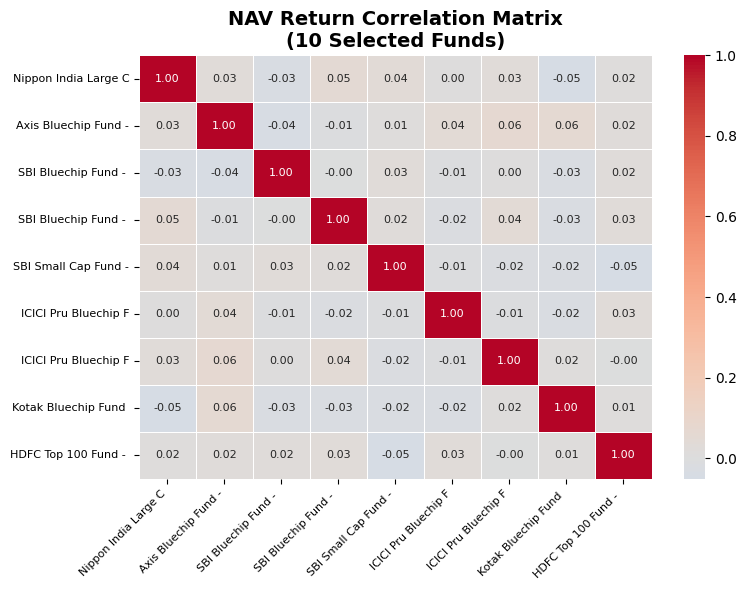

✅ Chart 8 saved → reports/charts/08_correlation_matrix.png


In [14]:
# Chart 8: NAV Return Correlation Matrix
df_nav = pd.read_csv("../data/processed/clean_nav.csv")
df_nav['date'] = pd.to_datetime(df_nav['date'])

# Select 10 funds
selected_codes = [119551, 120503, 125497, 118632, 
                  119092, 120841, 119597, 119598, 120504, 119552]

# Pivot to get NAV by fund
df_pivot = df_nav[df_nav['amfi_code'].isin(selected_codes)].pivot_table(
    index='date', columns='amfi_code', values='nav'
)

# Compute daily returns
df_returns = df_pivot.pct_change().dropna()

# Rename columns with short names
df_fund = pd.read_csv("../data/raw/01_fund_master.csv")
code_to_name = dict(zip(df_fund['amfi_code'], df_fund['scheme_name'].str[:20]))
df_returns.columns = [code_to_name.get(c, str(c)) for c in df_returns.columns]

# Correlation matrix
corr_matrix = df_returns.corr()

# Plot
plt.figure(figsize=(8, 6))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    linewidths=0.5,
    annot_kws={'size': 8}
)
plt.title('NAV Return Correlation Matrix\n(10 Selected Funds)', 
          fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.yticks(fontsize=8)
plt.tight_layout()

plt.savefig('../reports/charts/08_correlation_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart 8 saved → reports/charts/08_correlation_matrix.png")

In [15]:
# Chart 9: Sector Allocation Donut
df_holdings = pd.read_csv("../data/raw/09_portfolio_holdings.csv")
print(df_holdings.head())
print(df_holdings.columns.tolist())

   amfi_code stock_symbol                stock_name       sector  weight_pct  \
0     119551    POWERGRID    Power Grid Corporation    Utilities       13.85   
1     119551     HDFCBANK             HDFC Bank Ltd      Banking       11.19   
2     119551       GRASIM     Grasim Industries Ltd  Diversified        9.90   
3     119551      DRREDDY  Dr. Reddy's Laboratories       Pharma        4.76   
4     119551   ASIANPAINT          Asian Paints Ltd       Paints       10.25   

   market_value_cr  current_price_inr portfolio_date  
0           737.09            6011.08     2025-12-31  
1            88.97            1074.65     2025-12-31  
2           208.45            5964.59     2025-12-31  
3           161.32            3748.82     2025-12-31  
4           725.90            1321.45     2025-12-31  
['amfi_code', 'stock_symbol', 'stock_name', 'sector', 'weight_pct', 'market_value_cr', 'current_price_inr', 'portfolio_date']


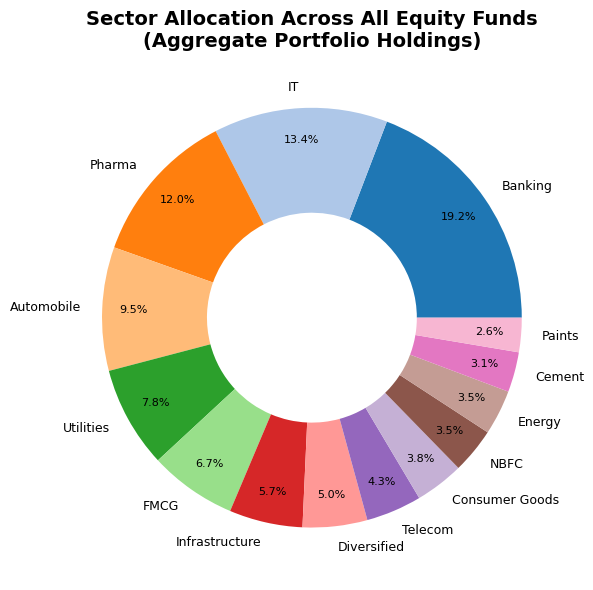

✅ Chart 9 saved → reports/charts/09_sector_allocation.png


In [17]:
# Chart 9: Sector Allocation Donut
# Aggregate sector weights across all equity funds
sector_weights = df_holdings.groupby('sector')['weight_pct'].sum().sort_values(ascending=False)

# Plot donut chart
fig, ax = plt.subplots(figsize=(10, 6))

wedges, texts, autotexts = ax.pie(
    sector_weights,
    labels=sector_weights.index,
    autopct='%1.1f%%',
    pctdistance=0.85,
    colors=sns.color_palette('tab20', len(sector_weights)),
    wedgeprops=dict(width=0.5)  # makes it a donut
)

# Style the text
for text in texts:
    text.set_fontsize(9)
for autotext in autotexts:
    autotext.set_fontsize(8)

ax.set_title('Sector Allocation Across All Equity Funds\n(Aggregate Portfolio Holdings)', 
             fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('../reports/charts/09_sector_allocation.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart 9 saved → reports/charts/09_sector_allocation.png")

# EDA Key Findings

## Finding 1 — NAV Trend
HDFC Top 100 Direct has the highest NAV at Rs.1,200+ showing strongest long-term growth among all selected funds from 2022-2026. [Chart 1]

## Finding 2 — AUM Dominance
SBI Mutual Fund dominates industry AUM at Rs.12.5 Lakh Crore in 2025, nearly 30% ahead of second-placed ICICI Prudential at Rs.9.8 Lakh Crore. [Chart 2]

## Finding 3 — SIP Growth
Monthly SIP inflows grew 2.7x from Rs.11,000 Crore (Jan 2022) to an all-time high of Rs.31,002 Crore (Dec 2025), reflecting India's deepening equity culture. [Chart 3]

## Finding 4 — Liquid Fund Dominance
Liquid funds receive the highest net inflows consistently across all months in FY 2024-25, indicating strong preference for short-term parking of funds. [Chart 4]

## Finding 5 — Young Investors Lead
The 26-35 age group dominates with 41.1% of all investors, while older investors (46-55, 56+) invest significantly higher SIP amounts per transaction. [Chart 5]

## Finding 6 — Geographic Spread
Madhya Pradesh and Punjab lead in total SIP amounts, while T30 cities contribute 66.3% of all investments vs B30 cities at 33.7%. [Chart 6]

## Finding 7 — Folio Doubling
Total mutual fund folios doubled from 13.26 Crore (Jan 2022) to 26.12 Crore (Dec 2025), with equity folios driving most of the growth. [Chart 7]

## Finding 8 — Low Correlation
All 10 selected funds show very low pairwise return correlations (0.01-0.06), indicating strong diversification benefits when combining multiple funds. [Chart 8]

## Finding 9 — Banking Sector Dominance
Banking sector accounts for 19.2% of aggregate equity fund holdings, followed by IT at 13.4% and Pharma at 12.0%, reflecting India's economic structure. [Chart 9]

## Finding 10 — Gender Gap
Male investors account for 66.5% of all transactions vs Female at 33.5%, highlighting a significant gender gap in mutual fund participation in India.